# Random Forest Model Training


## Load Cleaned Data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_train = pd.read_csv('data/clean_train.csv')
clean_val = pd.read_csv('data/clean_val.csv')

X_tr = clean_train.drop(columns=['target'])
y_tr = clean_train['target']
X_val = clean_val.drop(columns=['target'])
y_val = clean_val['target']

print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)


X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Target Skewness


Skewness: 2.09


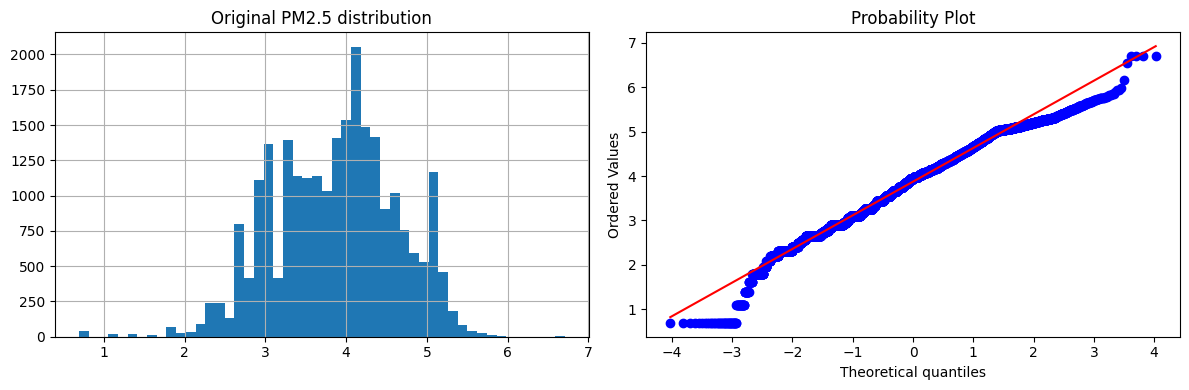

In [4]:
#Handle the target skewness by applying a log transform

import scipy.stats as stats

print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error

# Step 1 — train default model on all 70 features
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr_log)

y_val_pred = np.expm1(rf.predict(X_val))
rmse_default = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Default RF RMSE (all features): {rmse_default:.2f} µg/m³")

# Step 2 — tune with RandomizedSearchCV on all 70 features
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

search_rf = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                               param_grid, n_iter=30,
                               cv=5, scoring='neg_root_mean_squared_error',
                               random_state=42, n_jobs=-1, verbose=1)
search_rf.fit(X_tr, y_tr_log)

print("Best params:", search_rf.best_params_)

# Step 3 — evaluate best model
best_rf = search_rf.best_estimator_
y_val_pred_tuned = np.expm1(best_rf.predict(X_val))
rmse_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned))

print(f"Default RF RMSE (all features): {rmse_default:.2f} µg/m³")
print(f"Tuned RF RMSE   (all features): {rmse_tuned:.2f} µg/m³")
print(f"Improvement:                    {rmse_default - rmse_tuned:.2f} µg/m³")


Default RF RMSE (all features): 30.76 µg/m³
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Default RF RMSE (all features): 30.76 µg/m³
Tuned RF RMSE   (all features): 31.12 µg/m³
Improvement:                    -0.36 µg/m³


In [ ]:
# Now we do apply Random Forest to select top 25 best features

# Step 1 — feature selection using RF importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_tr, y_tr_log)

importance = pd.Series(rf_selector.feature_importances_, index=X_tr.columns)
top_features = importance.sort_values(ascending=False).head(25).index.tolist()

print("Top 25 features:")
print(importance.sort_values(ascending=False).head(25))

# Step 2 — select top features
X_tr_25 = X_tr[top_features]
X_val_25 = X_val[top_features]

# Step 3 — train final model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_tr_25, y_tr_log)

# Step 4 — evaluate
y_val_pred_25 = np.expm1(rf_model.predict(X_val_25))  # reverse log transform
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_25))
print(f"\nValidation RMSE: {rmse:.2f} µg/m³")


Top 25 features:
L3_AER_AI_sensor_altitude                              0.136147
L3_CO_CO_column_number_density                         0.106601
L3_HCHO_tropospheric_HCHO_column_number_density        0.056768
temperature_2m_above_ground                            0.047020
u_component_of_wind_10m_above_ground                   0.046100
L3_NO2_NO2_column_number_density                       0.043247
v_component_of_wind_10m_above_ground                   0.039213
L3_NO2_NO2_slant_column_number_density                 0.033225
specific_humidity_2m_above_ground                      0.024635
L3_CLOUD_surface_albedo                                0.023569
relative_humidity_2m_above_ground                      0.022538
L3_NO2_tropopause_pressure                             0.021300
precipitable_water_entire_atmosphere                   0.018408
L3_O3_O3_column_number_density                         0.017607
L3_O3_O3_effective_temperature                         0.017198
day_number             

/Users/karina/neuefische_course/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/karina/neuefische_course/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [23]:
#tune hyperparameters with RSCV for the top 25 best features

# Step 3 — run RandomizedSearchCV on top 25 features
param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

search_rf_25 = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                                  param_grid, n_iter=30,
                                  cv=5, scoring='neg_root_mean_squared_error',
                                  random_state=42, n_jobs=-1, verbose=1)
search_rf_25.fit(X_tr_25, y_tr_log)

print("Best params:", search_rf_25.best_params_)

# Step 4 — evaluate
best_rf_25 = search_rf_25.best_estimator_
y_val_pred_b25 = np.expm1(best_rf_25.predict(X_val_25))
rmse_rf_25 = np.sqrt(mean_squared_error(y_val, y_val_pred_b25))

print(f"Tuned RF RMSE (all 70 features):  {rmse_tuned:.2f} µg/m³")
print(f"Tuned RF RMSE (top 25 features):  {rmse_rf_25:.2f} µg/m³")
print(f"Improvement:                       {rmse_tuned - rmse_rf_25:.2f} µg/m³")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Tuned RF RMSE (all 70 features):  31.12 µg/m³
Tuned RF RMSE (top 25 features):  30.98 µg/m³
Improvement:                       0.14 µg/m³


In [6]:
print(y_tr.describe())


count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


In [7]:
mean_pm25 = y_tr.mean()
print(f"Mean PM2.5: {mean_pm25:.2f} µg/m³")
print(f"RMSE as % of mean: {(rmse / mean_pm25) * 100:.1f}%")


Mean PM2.5: 62.03 µg/m³
RMSE as % of mean: 51.6%


In [ ]:
# Save feature importance for use in XGBoost modeling notebook
importance.to_csv('data/feature_importance_rf.csv', header=['importance'])
print("Saved feature importance to data/feature_importance_rf.csv")


Saved feature importance to data/feature_importance_rf.csv


In [22]:
#print summary of all the results calculated above 
results = pd.DataFrame({
    'Model': [
        'Random Forest default (15 features)',
        'Random Forest tuned (all 70 features)',
        'Random Forest tuned (top 25 features)',
        'XGBoost default (25 features)',
        'XGBoost tuned (all features)',
        'XGBoost tuned (25 features)'
    ],
    'RMSE': [
        32.03,
        rmse_tuned,
        rmse_rf_25,
        31.87,
        29.32,
        30.40
    ]
})

results = results.sort_values('RMSE').reset_index(drop=True)
results.style.highlight_min(subset=['RMSE'], color='lightgreen')


,Model,RMSE
0,XGBoost tuned (all features),29.320000
1,XGBoost tuned (25 features),30.400000
2,Random Forest tuned (top 25 features),30.979468
3,Random Forest tuned (all 70 features),31.118790
4,XGBoost default (25 features),31.870000
5,Random Forest default (15 features),32.030000


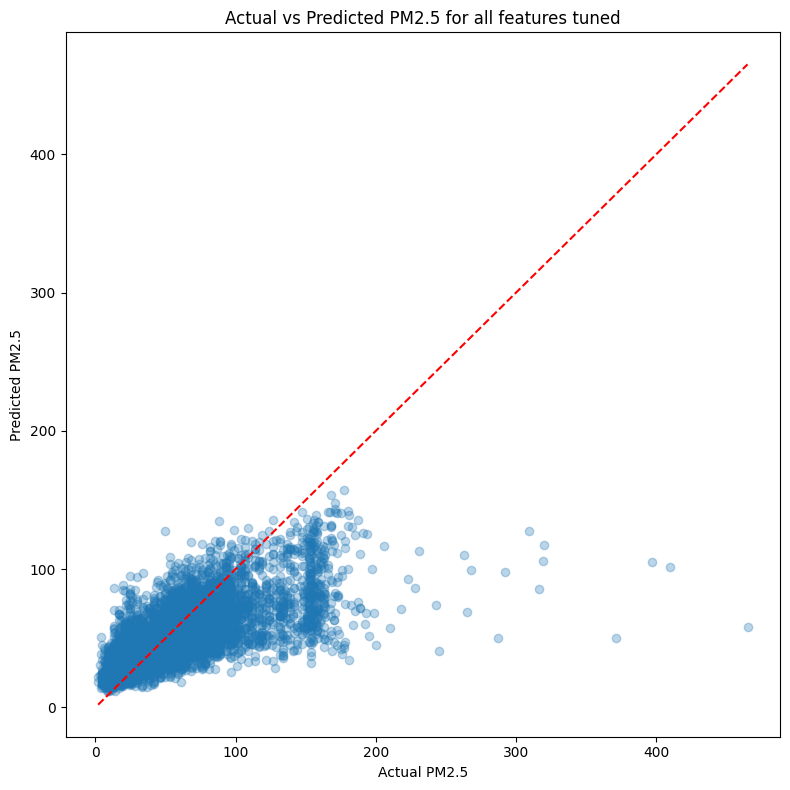

In [35]:
#Actual vs Predicted using RF all features and tuned
plt.figure(figsize=(8, 8))
plt.scatter(y_val, y_val_pred_tuned, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5 for all features tuned")
plt.tight_layout()
plt.show()


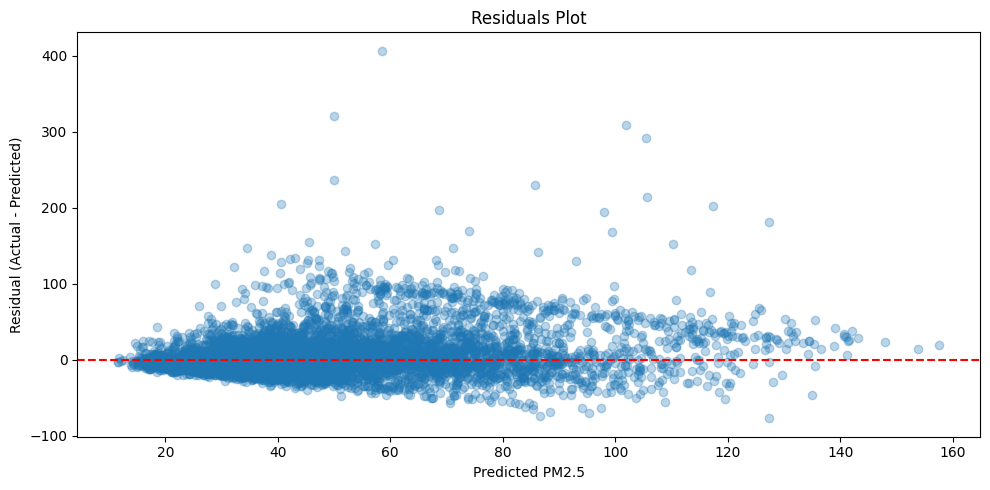

In [ ]:
#Residual Plot (model is over/under predicting)
residuals = y_val - y_val_pred_tuned

plt.figure(figsize=(10, 5))
plt.scatter(y_val_pred_tuned, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals Plot using all features in RF tuned")
plt.tight_layout()
plt.show()


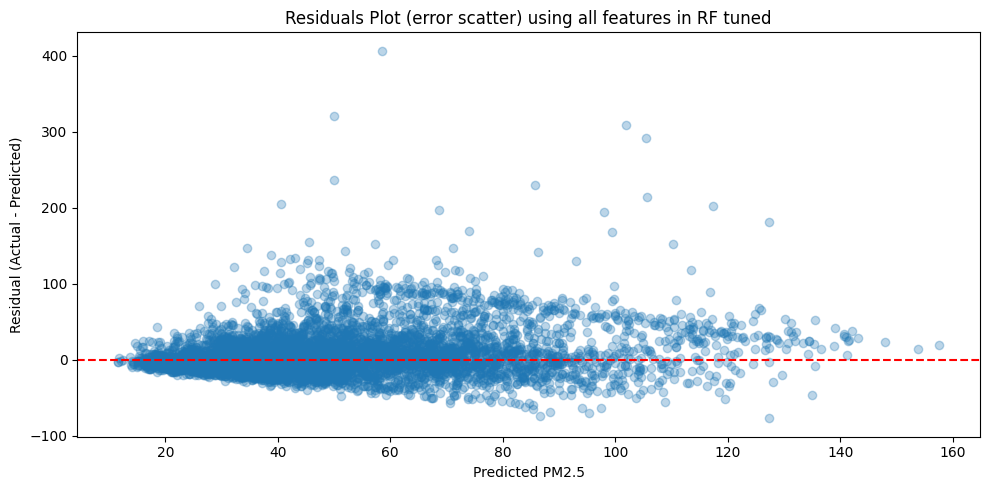

In [31]:
#Error Patterns in residuals 
residuals = y_val - y_val_pred_tuned

plt.figure(figsize=(10, 5))
plt.scatter(y_val_pred_tuned, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals Plot (error scatter) using all features in RF tuned")
plt.tight_layout()
plt.show()


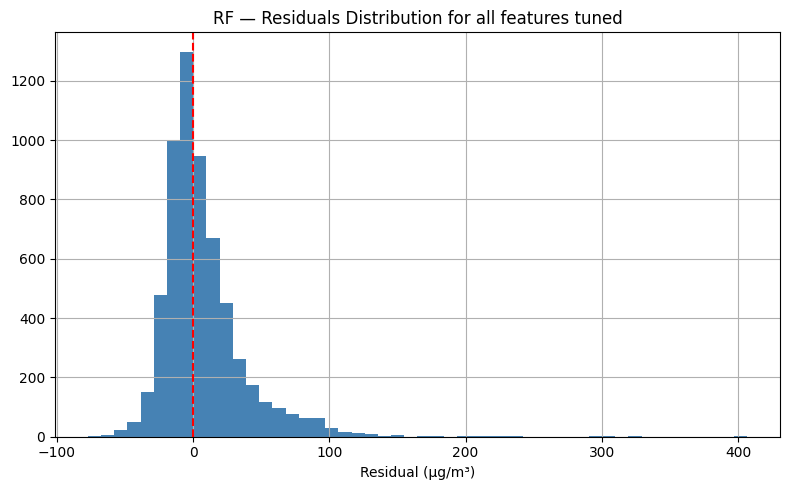

In [37]:

# Residuals distribution
plt.figure(figsize=(8, 5))
residuals.hist(bins=50, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (µg/m³)")
plt.title("RF — Residuals Distribution for all features tuned")
plt.tight_layout()
plt.show()

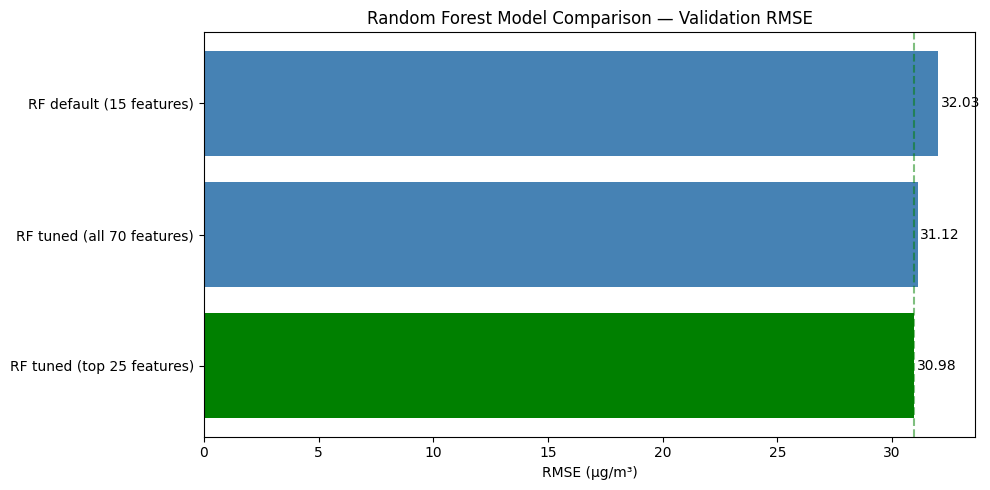

In [32]:
rf_results = pd.DataFrame({
    'Model': [
        'RF default (15 features)',
        'RF tuned (all 70 features)',
        'RF tuned (top 25 features)'
    ],
    'RMSE': [
        32.03,
        31.12,
        30.98
    ]
})

rf_results = rf_results.sort_values('RMSE').reset_index(drop=True)

plt.figure(figsize=(10, 5))
colors = ['green' if r == rf_results['RMSE'].min() else 'steelblue' for r in rf_results['RMSE']]
plt.barh(rf_results['Model'], rf_results['RMSE'], color=colors)
plt.xlabel('RMSE (µg/m³)')
plt.title('Random Forest Model Comparison — Validation RMSE')
plt.axvline(x=rf_results['RMSE'].min(), color='green', linestyle='--', alpha=0.5)
for i, v in enumerate(rf_results['RMSE']):
    plt.text(v + 0.1, i, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()
